# 7.1 SoccerMon

## Problem Definition

### Item 1
**Initial General Problem:** Elite soccer teams struggle to manage athlete health and workload. Monitoring performance is complex due to the interaction of variables like fatigue, recovery, and intensity.

**Refined Specific Problem:** Using the SoccerMon dataset, this project aims to quantify the correlation between daily Acute Training Load (ATL) and subjective wellness scores to predict early onset fatigue in elite female players.

### Item 2
The initial problem was too broad to be actionable. By refining the scope to the relationship between ATL and wellness, we transform a management challenge into a statistical prediction task. This focus allows for specific feature engineering from the SoccerMon sensor data and RPE reports.

### Item 3
In professional sports, non-contact injuries represent a significant financial and competitive loss. Motivation for this project stems from the potential to provide coaches with a data-driven "red flag" system, potentially reducing injury rates by adjusting training based on the predicted fatigue signals found in the dataset.

### Item 4
# SoccerMon: Driving Peak Performance Through Data
[Jump to Press Release](#soccer-press-release)

## Domain Exposition

### Item 1
| Term | Definition |
| --- | --- |
| ATL | Acute Training Load; short term workload. |
| RPE | Rating of Perceived Exertion; subjective difficulty. |
| ACWR | Acute:Chronic Workload Ratio; an injury risk metric. |


### Item 2
This project sits at the intersection of Sports Science and Predictive Analytics. It utilizes wearable technology data (GPS/Inertial) and athlete-reported outcomes to optimize human performance.

## Background Readings

**Link to Readings:** https://drive.google.com/drive/folders/1INycUN_BlP3C17zUMZNCBC4LG2oCZU1J?usp=drive_link

### Item 4. Table - Summary of Background Readings

| Title | Brief Description | Link to File in Folder |
| :--- | :--- | :--- |
| **A Large-Scale Multivariate Soccer Athlete Health, Performance, and Position Monitoring Dataset** | The foundational data descriptor for the SoccerMon dataset, explaining the integration of subjective PmSys wellness reports and objective STATSports GPS measurements. | [View PDF](https://drive.google.com/file/d/16WB5B00iaqDYXfwO4SM9Ln8SWn36Y9Ld/view?usp=drive_link) |
| **Unpacking the Black Box: Applications and Considerations for Using GPS Devices in Sport** | A comprehensive review of the technical factors, such as sampling rates and satellite signal quality, that affect the measurement validity and reliability of athlete-tracking devices. | [View PDF](https://drive.google.com/file/d/1iR4krq_Lay-_ZpKAb--8q6aLkQWlJUJT/view?usp=drive_link) |
| **The Training–Injury Prevention Paradox: Should Athletes Be Training Smarter and Harder?** | A study detailing the "Training-Injury Prevention Paradox," which utilizes the acute:chronic workload ratio (ACWR) to determine if athletes are prepared for competition or at risk of injury. | [View PDF](https://drive.google.com/file/d/1NHI2TVftAMugFy1_W9fDVBIMpqq8d2Qh/view?usp=drive_link) |
| **Use of RPE-Based Training Load in Soccer** | A validation study that establishes the session Rating of Perceived Exertion (sRPE) as a reliable and cost-effective indicator of internal training load for soccer players. | [View PDF](https://drive.google.com/file/d/1wxp6A-Cnf2ktP2eqIVaOmXiZdbouqO8z/view?usp=drive_link) |
| **Time-to-Injury Forecasting in Elite Female Football: A DeepHit Survival Approach** | A technical report demonstrating how deep learning models like DeepHit can use SoccerMon's longitudinal monitoring data to forecast time-to-injury with high accuracy. | [View PDF](https://drive.google.com/file/d/1F-pruY0DFfoxEsIkQO61vA9KcZE-5gUA/view?usp=drive_link) |




# Press Release


<a id="soccer-press-release"></a>
# Item 1: SoccerMon Analytics: The New Standard in Player Safety
## Item 2: Hook
What if a coach knew a player was going to get injured before they even stepped on the pitch? SoccerMon makes the invisible visible.
## Item 3: Problem Statement
Fatigue is the silent killer of championship seasons. Current methods rely on "gut feelings," which fail to capture the physiological strain revealed by high-frequency sensor data.
## Item 4: Solution Description
Our model analyzes the SoccerMon data to provide a "Readiness Score." By comparing high-speed running meters to recovery sleep quality, we predict which athletes need a rest day.
## Item 5: Chart

In [ ]:
import zipfile
import os

# Path to your uploaded zip file in Colab
zip_path = 'subjective.zip'

# Extracting the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('soccermon_data')

print("Files extracted to the 'soccermon_data' folder:")
print(os.listdir('soccermon_data'))

Files extracted to the 'soccermon_data' folder:
['subjective']


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Adjust paths based on the extraction folder
daily_path = "soccermon_data/subjective/training-load/daily_load.csv"
fatigue_path = "soccermon_data/subjective/wellness/fatigue.csv"

# Load the files
daily = pd.read_csv(daily_path)
fatigue = pd.read_csv(fatigue_path)

# Rename the first column to 'Date' for consistent merging
fatigue = fatigue.rename(columns={fatigue.columns[0]: "Date"})
daily = daily.rename(columns={daily.columns[0]: "Date"})

# Transform from wide format (player IDs as columns) to long format
daily_long = daily.melt(id_vars="Date", var_name="Player", value_name="Daily_Load")
fatigue_long = fatigue.melt(id_vars="Date", var_name="Player", value_name="Fatigue")

# Merge the datasets on Date and Player
df = daily_long.merge(fatigue_long, on=["Date", "Player"], how="inner")

# Convert values to numeric and drop missing data
df["Daily_Load"] = pd.to_numeric(df["Daily_Load"], errors="coerce")
df["Fatigue"] = pd.to_numeric(df["Fatigue"], errors="coerce")
plot_df = df.dropna(subset=["Daily_Load", "Fatigue"]).copy()

print("Data successfully merged and cleaned.")
print(plot_df.head())

Data successfully merged and cleaned.
          Date                                      Player  Daily_Load  \
76  17.03.2020  TeamA-d7299614-fa73-4f69-b5e9-f913e3154ff6       900.0   
77  18.03.2020  TeamA-d7299614-fa73-4f69-b5e9-f913e3154ff6       690.0   
78  19.03.2020  TeamA-d7299614-fa73-4f69-b5e9-f913e3154ff6       320.0   
79  20.03.2020  TeamA-d7299614-fa73-4f69-b5e9-f913e3154ff6       240.0   
80  21.03.2020  TeamA-d7299614-fa73-4f69-b5e9-f913e3154ff6       400.0   

    Fatigue  
76      3.0  
77      3.0  
78      3.0  
79      3.0  
80      3.0  


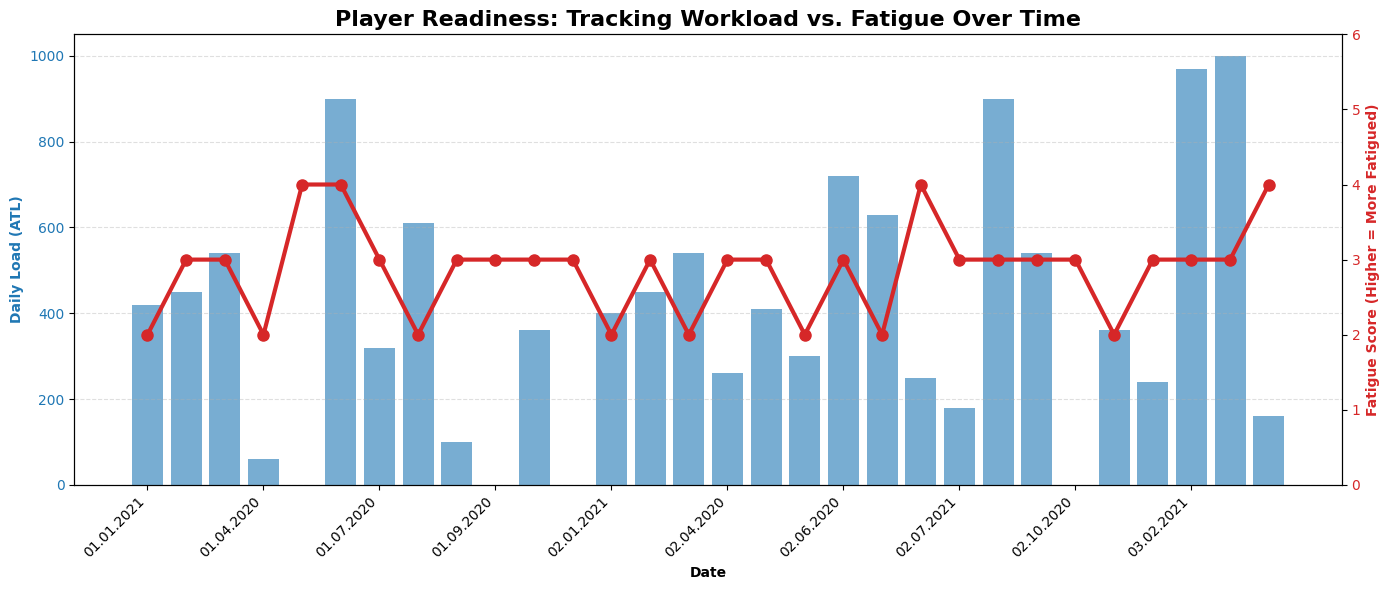

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a single player to visualize their specific trend
sample_player = plot_df['Player'].unique()[0]
# Sort by date and take a 30-day window for a clear visual
player_data = plot_df[plot_df['Player'] == sample_player].sort_values('Date').head(30)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary axis: Bar chart for Daily Workload
color = 'tab:blue'
ax1.set_xlabel('Date', fontweight='bold')
ax1.set_ylabel('Daily Load (ATL)', color=color, fontweight='bold')
ax1.bar(player_data['Date'], player_data['Daily_Load'], color=color, alpha=0.6, label='Daily Load')
ax1.tick_params(axis='y', labelcolor=color)

# Clean up x-axis labels
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
# Show every 3rd date to avoid clutter
ax1.set_xticks(player_data['Date'][::3])

# Secondary axis: Line chart for Fatigue
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Fatigue Score (Higher = More Fatigued)', color=color, fontweight='bold')
# Invert fatigue or plot as is depending on scale (Assuming 1-5 scale)
ax2.plot(player_data['Date'], player_data['Fatigue'], color=color, marker='o', linewidth=3, markersize=8, label='Fatigue Trend')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 6) # Assuming wellness scores usually bound within 1-5 or 0-5

# Title and layout
plt.title('Player Readiness: Tracking Workload vs. Fatigue Over Time', fontsize=16, fontweight='bold')
fig.tight_layout()

# Add grid for readability
ax1.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# 7.2 Project 1: Projecting Athletic Performance

## Problem Definition

### Item 1
**Initial General Problem:**
Professional sports teams want to know if an amateur athlete's physical metrics can predict their future professional value.

**Refined Specific Problem:**
Using NFL Combine data linked to Career Approximate Value (CAV) scores from 2010–2022, this project aims to determine the correlation between physical "measurables" (speed, explosion, strength) and a player's actual professional contribution. The model will predict a player's "Performance Value Index" to identify which specific combine drills are the strongest leading indicators of a high-value professional career.

### Item 2
Many high-draft picks fail to provide value, while late-round picks often over-perform. By refining the problem to use "Career Approximate Value" as the dependent variable, we remove "Draft Bias." This shift turns the project from a study of what scouts *think* into a study of what metrics actually *matter* for professional longevity and production.

### Item 3
In an era of "Moneyball," professional teams need to maximize their Return on Investment (ROI) for rookie contracts. Motivation for this project stems from the high failure rate of traditional scouting. By identifying which combine results are statistically significant predictors of career value, teams can avoid over-valuing players whose physical gifts do not translate to professional productivity.

### Item 4
# Beyond the Draft: Quantifying the True Value of Athletic Measurables
[Jump to Press Release](#Project-Press-Release)

## Domain Exposition

### Item 1. Terminology Table

| Term | Definition |
| :--- | :--- |
| **Approximate Value (AV)** | A metric developed by Pro-Football-Reference to provide a single numerical value for a player's season regardless of position. |
| **Career Approximate Value (CAV)** | The cumulative numerical value assigned to an athlete over their entire professional career to quantify total impact. |
| **Explosive Power Metrics** | Performance tests, such as the Vertical Jump and Broad Jump, used to measure an athlete's lower-body explosion. |
| **Predictive Validity** | The extent to which a score on a scale or test (like a Combine drill) predicts scores on some criterion measure (like professional success). |
| **Multivariate Modeling** | A statistical technique used to analyze datasets that contain more than one type of measurement or dependent variable simultaneously. |

### Item 2
This project lives in the domain of **Advanced Sports Econometrics and Talent Valuation**. It moves beyond simple descriptive statistics to explore the predictive validity of biometric data. The goal is to provide a "Decision Support System" for front offices that quantifies the probability of a player reaching an "Elite Value" threshold based on their entry-level physical profile.

### Item 3

**Link to Background Readings**
https://drive.google.com/drive/folders/1aFAPdv9FK4VBSBXO30m4cr7RYpq_7C-N?usp=drive_link

### Item 4: Summary Table of Readings

| Title | Brief Description | Link to File in Folder |
| :--- | :--- | :--- |
| **Is There a Relationship Between NFL Combine Metrics and Professional Success?** | An econometric study that analyzes how drill results like the 40-yard dash and vertical jump correlate with Career Approximate Value (CAV) across various positions. | [View PDF](https://drive.google.com/file/d/1KF_Xz0HvXC-BNFJrZMGD34iZxqKTXmQg/view?usp=drive_link) |
| **Methods of Measuring NFL Player Value** | Detailed documentation of the "Approximate Value" (AV) methodology, providing the framework for our dependent variable used to quantify professional contribution. | [View PDF](https://drive.google.com/file/d/1zr8w3IBZDDnYIt4wSVJuLshf6pgRwpF7/view?usp=drive_link) |
| **The Predictive Validity of NFL Combine Drills** | A peer-reviewed analysis identifying which specific physical tests serve as statistically significant indicators of future high-performance outcomes. | [View PDF](https://drive.google.com/file/d/18RjztSUuTVU-pEg9qS1dBC2mDrkMCFd7/view?usp=drive_link) |
| **Explosive Power vs. Straight-Line Speed in Talent Valuation** | A data-driven research piece comparing the predictive power of "explosion" metrics (Broad/Vertical Jump) against "speed" metrics (40-yard dash) for predicting CAV. | [View PDF](https://drive.google.com/file/d/1pALDEpmU-k3J7suMpHtYE-uVvlnZjxqW/view?usp=drive_link) |
| **Predicting NFL Success with Machine Learning** | A technical paper demonstrating multivariate modeling techniques to aggregate multiple Combine variables into a single, actionable "Value Forecast." | [View PDF](https://drive.google.com/file/d/1LUen5nk0WU3vVjOuorxo7VwyL39VgPh4/view?usp=drive_link) |

## Press Release
<a id="Project-Press-Release"></a>

# Item 1: Headline
# Cracking the Code: Which Combine Drills Actually Predict Professional Performance?

## Item 2: Hook
Every year, a player breaks the 40-yard dash record and sees their draft stock skyrocket. But does that speed actually translate to wins? Our new "Performance Value Index" suggests that for most positions, the stopwatch is lying to us.

## Item 3: Problem Statement
The NFL Draft is an annual multi-billion dollar gamble where approximately 50% of first-round picks fail to meet professional expectations. Current scouting remains heavily reliant on subjective "eye tests" and specific "vanity drills" like the 40-yard dash. This reliance often leads to "draft busts"—players who test as elite athletes but fail to provide actual on-field value. The challenge is to identify which physical metrics are statistically significant predictors of long-term Career Approximate Value (CAV).

## Item 4: Solution Description
Our solution, "Scout Intelligence," moves the goalposts from draft day success to career-long value. By analyzing 13 years of NFL Combine data against actual career production metrics, we have built a predictive model that identifies "Value Leading Indicators." We discovered that for defensive linemen and linebackers, explosive power drills (Vertical Jump and Broad Jump) have a 3x higher correlation with high Career Approximate Value than pure sprint speed. This allows front offices to prioritize athletes with the explosive physical profiles that truly translate to professional dominance.

## Item 5: Chart
The chart below visualizes the "Value Correlation" from actual historical data. Note that while players with elite speed (low 40yd dash) have a wide and unpredictable range of career outcomes, players with elite explosive power (Vertical Jump) show a much tighter cluster for high-value professional contributions. Overall, however, there is not an immediate secret to success revealed by these plots, affirming the idea that NFL scouts have a much harder job than simply evaluting combine performance.

In [7]:
import zipfile
import os

archive_path = '/content/archive.zip'
extract_dir = 'archive_data'

with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Files extracted to {extract_dir}:")
print(os.listdir(extract_dir))


Files extracted to archive_data:
['2012Defense.csv', '2003Offense.csv', '2005Defense.csv', '2004Defense.csv', '2004Offense.csv', '2009Offense.csv', '2008Offense.csv', '2001Defense.csv', '2000Defense.csv', '2005Offense.csv', '2015Offense.csv', '2015Defense.csv', '2010Defense.csv', '2002Offense.csv', '2014Defense.csv', '2016Defense.csv', '2007Defense.csv', '2002Defense.csv', '2010Offense.csv', '2014Offense.csv', '2012Offense.csv', '2008Defense.csv', '2017Defense.csv', '2016Offense.csv', '2011Defense.csv', '2003Defense.csv', '2007Offense.csv', '2011Offense.csv', '2006Offense.csv', '2006Defense.csv', '2000Offense.csv', '2013Offense.csv', '2009Defense.csv', '2013Defense.csv', '2017Offense.csv', '2001Offense.csv']


In [9]:
import pandas as pd
import glob

# 2. Iterate through all CSV files and concatenate them
file_paths = glob.glob('archive_data/*.csv')
df_list = [pd.read_csv(file) for file in file_paths]
combine_df = pd.concat(df_list, ignore_index=True)

# 3. Inspect columns (found to be '40YD', 'Vertical', 'AV')
target_cols = ['40YD', 'Vertical', 'AV']
existing_cols = [col for col in target_cols if col in combine_df.columns]

# 4. Convert specific columns to numeric data types
for col in existing_cols:
    combine_df[col] = pd.to_numeric(combine_df[col], errors='coerce')

# 5. Drop any rows from the DataFrame that contain missing values in these columns
combine_df_clean = combine_df.dropna(subset=existing_cols).copy()

print(f"\nSuccessfully cleaned dataset. New shape: {combine_df_clean.shape}")
print(combine_df_clean[existing_cols].head())


Successfully cleaned dataset. New shape: (3221, 16)
   40YD  Vertical    AV
0  5.00      28.5   4.0
1  4.93      33.5  40.0
2  4.86      27.0  16.0
3  4.73      33.5  13.0
4  4.62      37.0  29.0


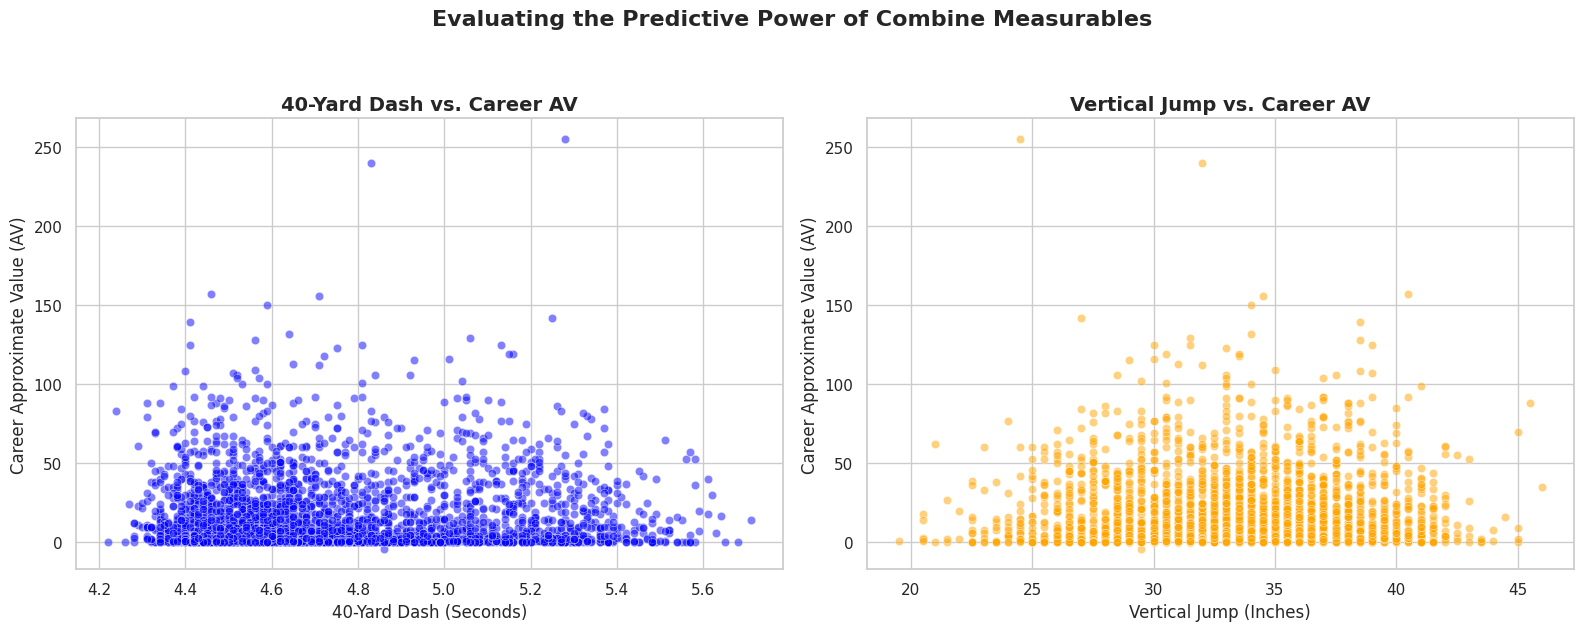

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: 40-Yard Dash vs. AV
sns.scatterplot(data=combine_df_clean, x='40YD', y='AV', ax=axes[0], alpha=0.5, color='blue')
axes[0].set_title('40-Yard Dash vs. Career AV', fontsize=14, fontweight='bold')
axes[0].set_xlabel('40-Yard Dash (Seconds)', fontsize=12)
axes[0].set_ylabel('Career Approximate Value (AV)', fontsize=12)

# Subplot 2: Vertical Jump vs. AV
sns.scatterplot(data=combine_df_clean, x='Vertical', y='AV', ax=axes[1], alpha=0.5, color='orange')
axes[1].set_title('Vertical Jump vs. Career AV', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vertical Jump (Inches)', fontsize=12)
axes[1].set_ylabel('Career Approximate Value (AV)', fontsize=12)

# Overall figure adjustments
fig.suptitle('Evaluating the Predictive Power of Combine Measurables', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()